<a href="https://colab.research.google.com/github/pankajmalav1991-a11y/Project-for-my-own-requirement/blob/main/ViT_ViViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Vision Transformer and Video Vision Transformer**

## *Transformer for spatial and spatio-temporal data:*
### Replacing convoltion by self-attention for learning image and video representation.

## **Vision Transformer**
(https://arxiv.org/pdf/2010.11929)

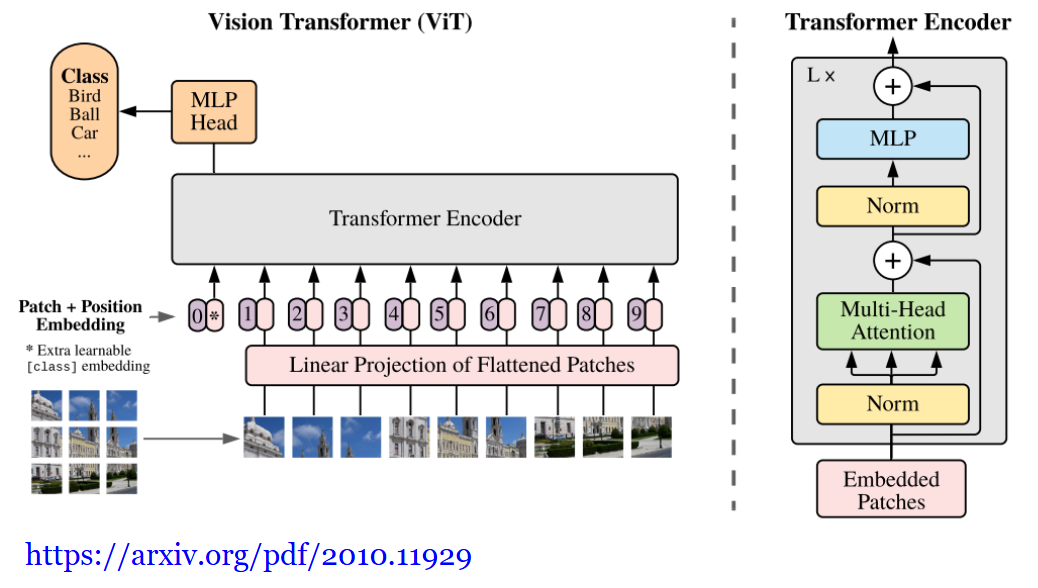

In [ ]:
import torch
import torch.nn as nn


class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        # Use Conv2d as a shortcut for splitting and embedding
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C, H, W] -> [B, E, H/P, W/P] -> [B, E, N] -> [B, N, E]
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

class ViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, num_classes=10, embed_dim=768, depth=6, heads=8, mlp_dim=2048):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=mlp_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        b = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.transformer(x)
        return self.mlp_head(x[:, 0]) # Classify using the CLS token

In [ ]:
from torch.utils.data import DataLoader, Dataset

class SyntheticDataset(Dataset):
    def __init__(self, mode="image", size=100):
        self.mode = mode
        self.size = size
    def __len__(self): return self.size
    def __getitem__(self, idx):
        if self.mode == "image":
            return torch.randn(3, 224, 224), torch.randint(0, 10, (1,)).item()
        else: # video
            return torch.randn(8, 3, 224, 224), torch.randint(0, 10, (1,)).item()

def run():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Initialize ViViT and DataLoader
    model = ViT().to(device)
    dataset = SyntheticDataset(mode="image")
    loader = DataLoader(dataset, batch_size=4, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    print("--- Starting Synthetic Training Demo ---")
    model.train()
    for i, (videos, labels) in enumerate(loader):
        videos, labels = videos.to(device), labels.to(device)

        outputs = model(videos)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 5 == 0:
            print(f"Batch {i}, Loss: {loss.item():.4f}")
        if i == 15: break # Stop early for demo

    # Testing Implementation
    model.eval()
    with torch.no_grad():
        test_image = torch.randn(1, 3, 224, 224).to(device)
        prediction = model(test_image)
        print(f"\nInference Successful. Output shape: {prediction.shape}")

if __name__ == "__main__":
    run()

--- Starting Synthetic Training Demo ---
Batch 0, Loss: 2.6781
Batch 5, Loss: 2.8269
Batch 10, Loss: 2.7675
Batch 15, Loss: 3.1510

Inference Successful. Output shape: torch.Size([1, 10])


# **Video Vision Transformer**

(https://arxiv.org/pdf/2103.15691)

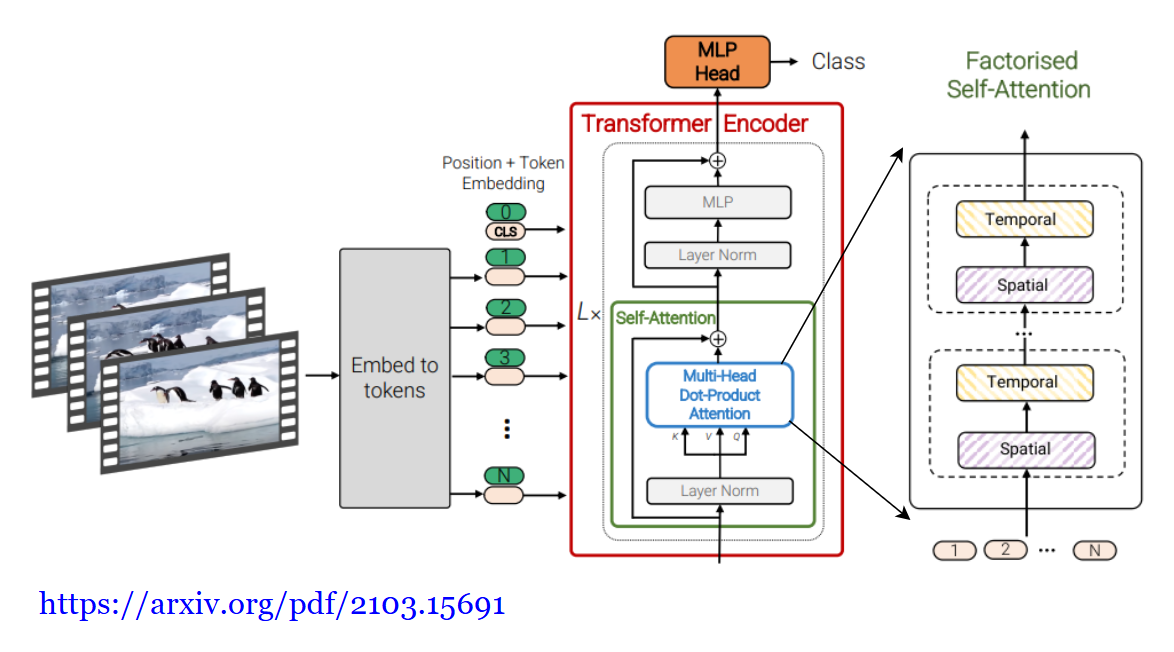

### *Tubelet Embedding*

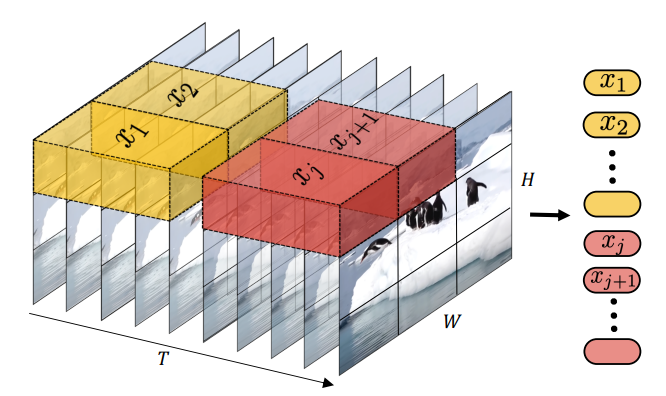

In [ ]:
import torch
import torch.nn as nn
from einops import rearrange

class TubeletEmbedding(nn.Module):
    def __init__(self, tubelet_size=(4, 16, 16), in_channels=3, embed_dim=768):
        """
        tubelet_size: (t_patch, h_patch, w_patch)
        """
        super().__init__()
        self.tubelet_size = tubelet_size
        # Use a 3D convolution to create the embedding
        self.proj = nn.Conv3d(
            in_channels,
            embed_dim,
            kernel_size=tubelet_size,
            stride=tubelet_size
        )

    def forward(self, x):
        # x shape: [Batch, Channels, Frames, Height, Width]
        x = self.proj(x) # [B, E, F', H', W']
        # Flatten the spatial and temporal dimensions into a sequence of tokens
        x = rearrange(x, 'b e f h w -> b (f h w) e')
        return x



class ViViT(nn.Module):
    def __init__(self, num_frames=16, img_size=224, tubelet_size=(4, 16, 16),
                 num_classes=10, embed_dim=768, spatial_depth=6, temporal_depth=6, heads=8):
        super().__init__()

        self.tubelet_embed = TubeletEmbedding(tubelet_size, 3, embed_dim)

        # Calculate number of tokens
        self.num_t = num_frames // tubelet_size[0]
        self.num_h = img_size // tubelet_size[1]
        self.num_w = img_size // tubelet_size[2]
        self.num_spatial_tokens = self.num_h * self.num_w

        # Positional Embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_spatial_tokens, embed_dim))
        self.temp_embed = nn.Parameter(torch.zeros(1, self.num_t, embed_dim))

        # Spatial Transformer Encoder
        spatial_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, batch_first=True)
        self.spatial_transformer = nn.TransformerEncoder(spatial_layer, num_layers=spatial_depth)

        # Temporal Transformer Encoder
        temporal_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, batch_first=True)
        self.temporal_transformer = nn.TransformerEncoder(temporal_layer, num_layers=temporal_depth)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        # Input x: [B, C, F, H, W]
        b = x.shape[0]

        # 1. Tubelet Embedding
        x = self.tubelet_embed(x) # [B, T*H*W, E]

        # 2. Spatial Factorization
        # Reshape to process spatial patches per time step
        x = rearrange(x, 'b (t s) e -> (b t) s e', t=self.num_t)
        x = x + self.pos_embed
        x = self.spatial_transformer(x)

        # Global Average Pooling over spatial tokens
        x = x.mean(dim=1) # [(B*T), E]

        # 3. Temporal Factorization
        # Reshape back to sequence of temporal tokens
        x = rearrange(x, '(b t) e -> b t e', b=b)
        x = x + self.temp_embed
        x = self.temporal_transformer(x)

        # 4. Final Classification
        return self.mlp_head(x.mean(dim=1))

In [ ]:
def train_vivit():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Hyperparameters
    num_frames = 16
    img_size = 224
    batch_size = 2

    model = ViViT(num_frames=num_frames, img_size=img_size).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    # Synthetic Video Data: [Batch, Channels, Frames, Height, Width]
    # Note: Tubelet size (2,16,16) means we need frames to be divisible by 2
    dummy_videos = torch.randn(batch_size, 3, num_frames, img_size, img_size).to(device)
    dummy_labels = torch.randint(0, 10, (batch_size,)).to(device)

    # Training Step
    model.train()
    outputs = model(dummy_videos)
    loss = criterion(outputs, dummy_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Factorized ViViT Step Complete. Loss: {loss.item():.4f}")

    # Inference Test
    model.eval()
    with torch.no_grad():
        out = model(dummy_videos)
        probs = torch.softmax(out, dim=-1)
        print(f"Inference Output (Probs): {probs.shape}")

if __name__ == "__main__":
    train_vivit()

Factorized ViViT Step Complete. Loss: 2.3296
Inference Output (Probs): torch.Size([2, 10])
